# **#Part 1 – Data Collection and Preprocessing**

In [10]:
!pip -q install statsmodels seaborn

1.1 *Importing* Required Libraries

In [11]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use("ggplot")

print("Libraries Imported Successfully")

Libraries Imported Successfully


**1.2 **Loading** the German Electricity Demand *Dataset***

In [12]:
file_path = "/content/drive/MyDrive/MACHINE LEARNING PROJECT/time_series_60min_singleindex.csv"

1.3 Data Cleaning

In [13]:
import pandas as pd

df = pd.read_csv(
    file_path,
    parse_dates=["utc_timestamp"]
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (50401, 300)


,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
0,2014-12-31 23:00:00+00:00,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01 00:00:00+00:00,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01 01:00:00+00:00,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,...,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
3,2015-01-01 02:00:00+00:00,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,...,1004.79,805.0,NaN,1.04,2626.0,2810.0,3.8,NaN,NaN,NaN
4,2015-01-01 03:00:00+00:00,2015-01-01T04:00:00+0100,5249.0,6454.0,38.0,NaN,64.0,8567.0,8909.0,NaN,...,983.79,803.0,NaN,1.61,2618.0,2780.0,3.8,NaN,NaN,NaN


1.4 Resampling the Time Series

In [14]:
df.describe()

,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,BE_wind_generation_actual,BE_wind_offshore_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
count,50400.000000,50400.000000,32845.000000,50339.000000,50352.000000,50400.000000,50376.000000,50385.000000,46466.000000,46466.000000,...,50340.000000,50398.000000,50391.000000,50379.000000,5.037300e+04,50398.000000,50010.000000,9679.000000,25635.000000,25413.000000
mean,7070.148631,7039.848552,33.934663,135.280121,729.653261,9808.383929,9759.323567,393.402158,779.920474,433.482914,...,1462.742614,1465.434762,31.886199,0.546785,3.336826e+03,3288.454423,60.563224,0.684807,17006.680807,17290.802306
std,1400.263167,1355.382837,14.944863,198.955378,692.002497,1393.548610,1380.214097,621.803385,665.931016,400.823333,...,262.562188,260.132266,47.972831,0.726016,9.678832e+03,457.612965,91.983827,2.531283,2776.794985,2741.479932
min,664.000000,3739.000000,-76.000000,0.000000,0.000000,6245.000000,6522.000000,0.000000,1.090000,0.000000,...,24.240000,753.000000,0.000000,0.000000,1.830000e+03,2040.000000,0.000000,0.000000,10905.000000,11450.000000
25%,5941.000000,5941.000000,25.000000,0.000000,162.000000,8706.000000,8671.000000,0.000000,245.532500,103.652500,...,1252.360000,1253.000000,0.040000,0.000000,2.942000e+03,2940.000000,0.000000,0.000000,15048.000000,15420.000000
50%,7032.000000,7018.000000,33.000000,18.000000,493.000000,9809.000000,9757.000000,10.670000,571.515000,317.345000,...,1463.970000,1474.000000,1.850000,0.270000,3.295000e+03,3300.000000,2.900000,0.300000,16678.000000,16905.000000
75%,8079.000000,7986.000000,42.000000,224.000000,1141.000000,10852.000000,10813.250000,596.400000,1171.482500,650.000000,...,1658.702500,1662.000000,52.530000,0.790000,3.600000e+03,3600.000000,97.900000,0.800000,18862.000000,19173.000000
max,10803.000000,11608.000000,187.000000,1166.000000,2969.000000,13670.000000,13454.000000,3281.400000,3252.680000,1944.160000,...,2402.250000,2206.000000,717.820000,4.670000,2.170811e+06,4520.000000,387.200000,36.500000,24684.000000,24739.000000


In [15]:
df = df[[
    "utc_timestamp",
    "DE_load_actual_entsoe_transparency"
]]

df.head()

,utc_timestamp,DE_load_actual_entsoe_transparency
0,2014-12-31 23:00:00+00:00,NaN
1,2015-01-01 00:00:00+00:00,41151.0
2,2015-01-01 01:00:00+00:00,40135.0
3,2015-01-01 02:00:00+00:00,39106.0
4,2015-01-01 03:00:00+00:00,38765.0


In [16]:
df.columns = [
    "timestamp",
    "load"
]

df.head()

,timestamp,load
0,2014-12-31 23:00:00+00:00,NaN
1,2015-01-01 00:00:00+00:00,41151.0
2,2015-01-01 01:00:00+00:00,40135.0
3,2015-01-01 02:00:00+00:00,39106.0
4,2015-01-01 03:00:00+00:00,38765.0


In [17]:
df = df.dropna()

print(df.shape)

(50400, 2)


In [18]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.set_index("timestamp")

df = df.sort_index()

print(df.index)

DatetimeIndex(['2015-01-01 00:00:00+00:00', '2015-01-01 01:00:00+00:00',
               '2015-01-01 02:00:00+00:00', '2015-01-01 03:00:00+00:00',
               '2015-01-01 04:00:00+00:00', '2015-01-01 05:00:00+00:00',
               '2015-01-01 06:00:00+00:00', '2015-01-01 07:00:00+00:00',
               '2015-01-01 08:00:00+00:00', '2015-01-01 09:00:00+00:00',
               ...
               '2020-09-30 14:00:00+00:00', '2020-09-30 15:00:00+00:00',
               '2020-09-30 16:00:00+00:00', '2020-09-30 17:00:00+00:00',
               '2020-09-30 18:00:00+00:00', '2020-09-30 19:00:00+00:00',
               '2020-09-30 20:00:00+00:00', '2020-09-30 21:00:00+00:00',
               '2020-09-30 22:00:00+00:00', '2020-09-30 23:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='timestamp', length=50400, freq=None)


In [19]:
df = df.loc["2015-01-01":"2020-10-31"]

print(df.shape)

(50400, 1)


In [20]:
daily = df.resample("D").mean()

weekly = df.resample("W").mean()

print(daily.head())

print(weekly.head())

                                   load
timestamp                              
2015-01-01 00:00:00+00:00  45346.541667
2015-01-02 00:00:00+00:00  51941.166667
2015-01-03 00:00:00+00:00  46564.750000
2015-01-04 00:00:00+00:00  45082.500000
2015-01-05 00:00:00+00:00  55246.666667
                                   load
timestamp                              
2015-01-04 00:00:00+00:00  47233.739583
2015-01-11 00:00:00+00:00  56191.101190
2015-01-18 00:00:00+00:00  57672.678571
2015-01-25 00:00:00+00:00  58613.303571
2015-02-01 00:00:00+00:00  58734.029762


In [21]:
df.describe()

,load
count,50400.000000
mean,55492.468552
std,10015.431042
min,31307.000000
25%,47106.000000
50%,55092.000000
75%,64309.250000
max,77549.000000


In [22]:
daily = df.resample("D").mean()

daily.head()

,load
timestamp,
2015-01-01 00:00:00+00:00,45346.541667
2015-01-02 00:00:00+00:00,51941.166667
2015-01-03 00:00:00+00:00,46564.750000
2015-01-04 00:00:00+00:00,45082.500000
2015-01-05 00:00:00+00:00,55246.666667


In [23]:
weekly = df.resample("W").mean()

weekly.head()

,load
timestamp,
2015-01-04 00:00:00+00:00,47233.739583
2015-01-11 00:00:00+00:00,56191.101190
2015-01-18 00:00:00+00:00,57672.678571
2015-01-25 00:00:00+00:00,58613.303571
2015-02-01 00:00:00+00:00,58734.029762


1.5 Exploratory Data Analysis (EDA)

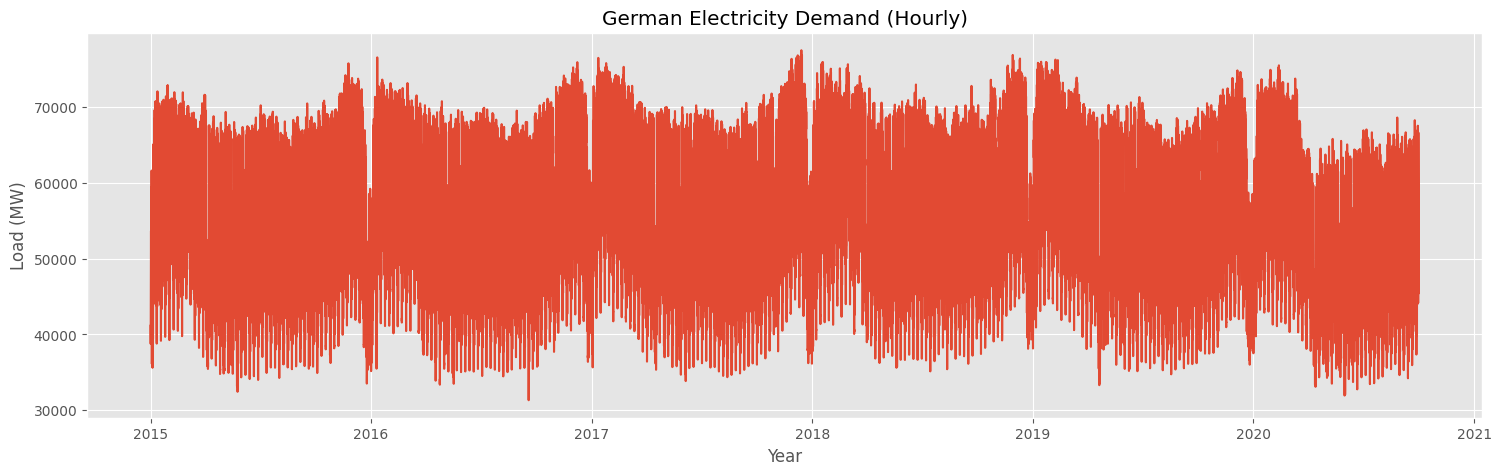

In [24]:
plt.figure(figsize=(18,5))

plt.plot(df.index, df["load"])

plt.title("German Electricity Demand (Hourly)")

plt.xlabel("Year")

plt.ylabel("Load (MW)")

plt.show()

**Daily Average Electricity Demand**

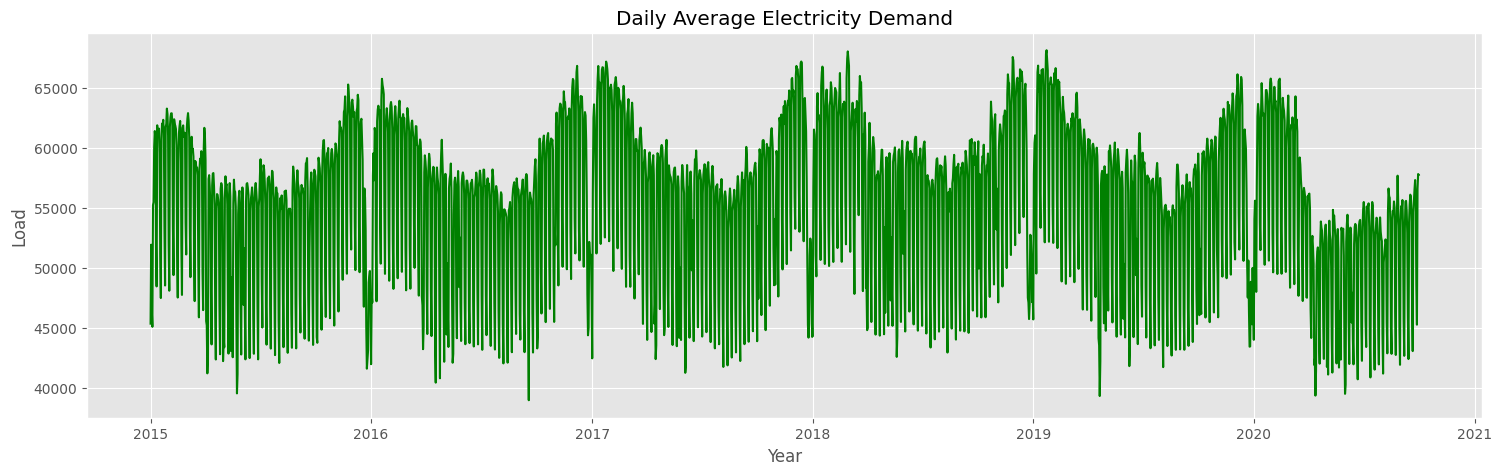

In [25]:
plt.figure(figsize=(18,5))

plt.plot(
    daily.index,
    daily["load"],
    color="green"
)

plt.title("Daily Average Electricity Demand")

plt.xlabel("Year")

plt.ylabel("Load")

plt.show()

**Weekly Average Electricity Demand**

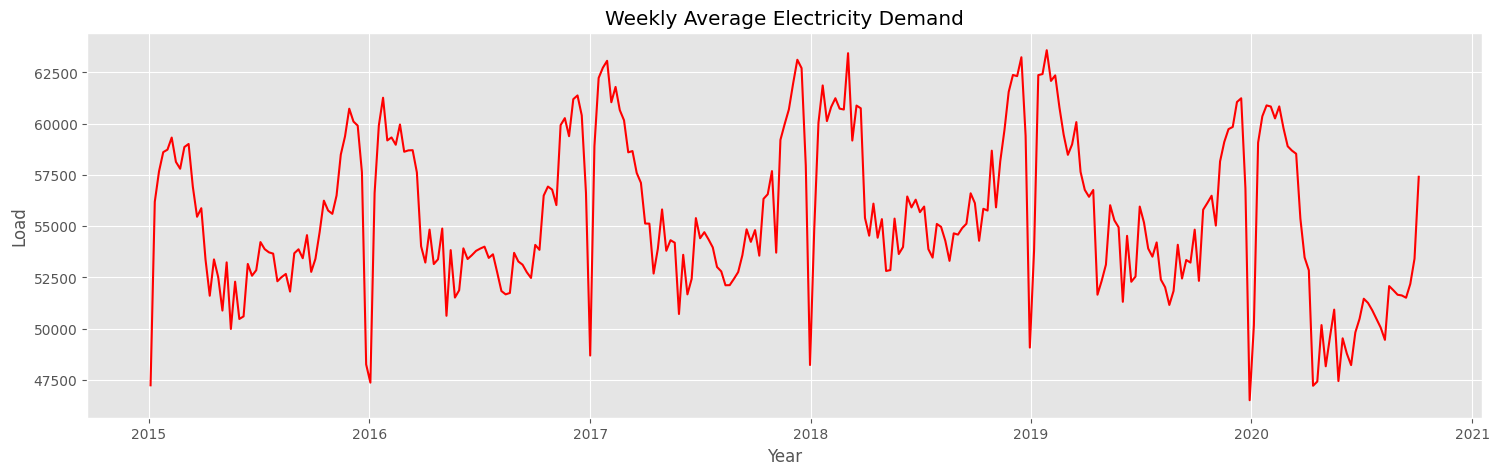

In [26]:
plt.figure(figsize=(18,5))

plt.plot(
    weekly.index,
    weekly["load"],
    color="red"
)

plt.title("Weekly Average Electricity Demand")

plt.xlabel("Year")

plt.ylabel("Load")

plt.show()

**Distribution of Weekly Electricity Demand**

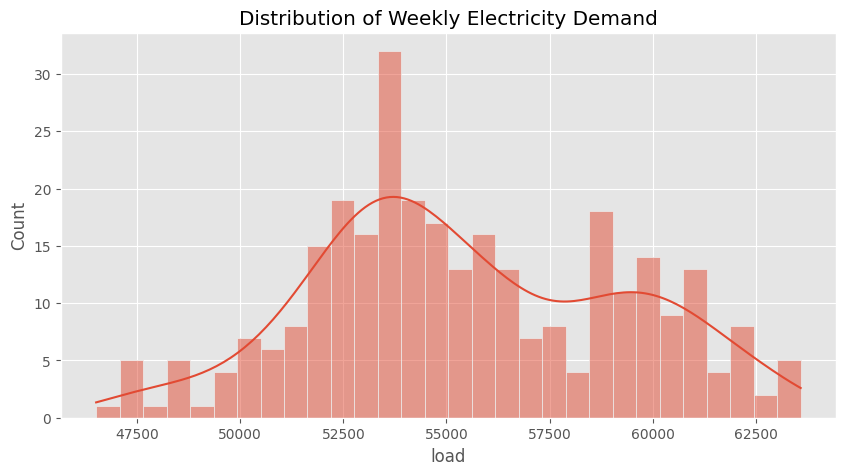

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(
    weekly["load"],
    bins=30,
    kde=True
)

plt.title("Distribution of Weekly Electricity Demand")

plt.show()

**Weekly Electricity Demand Boxplot**

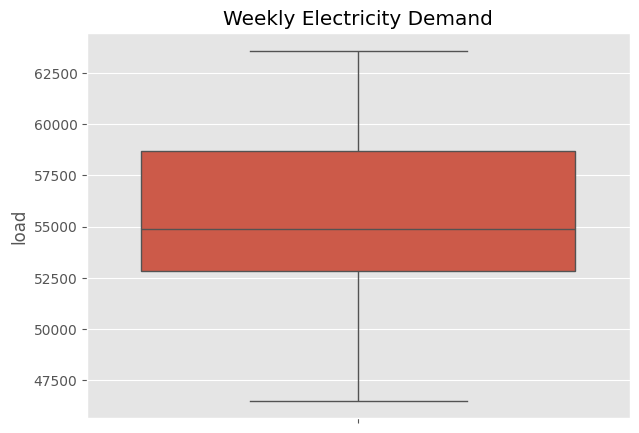

In [28]:
plt.figure(figsize=(7,5))

sns.boxplot(
    y=weekly["load"]
)

plt.title("Weekly Electricity Demand")

plt.show()

**Seasonal Decomposition**

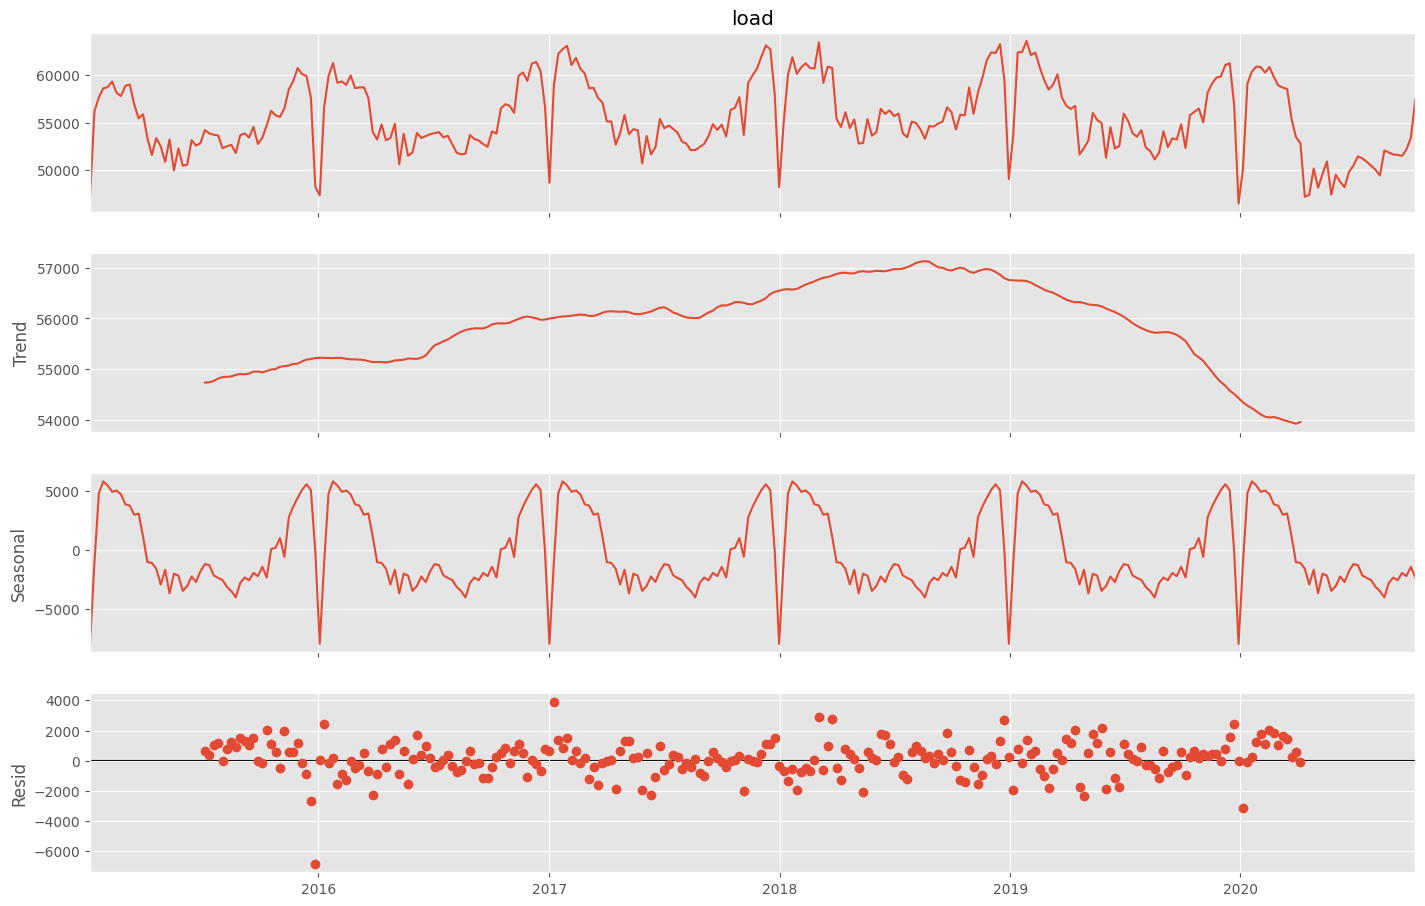

In [29]:
decomposition = seasonal_decompose(
    weekly["load"],
    model="additive",
    period=52
)

fig = decomposition.plot()

fig.set_size_inches(16,10)

plt.show()

**1.6 Rolling Statistics**

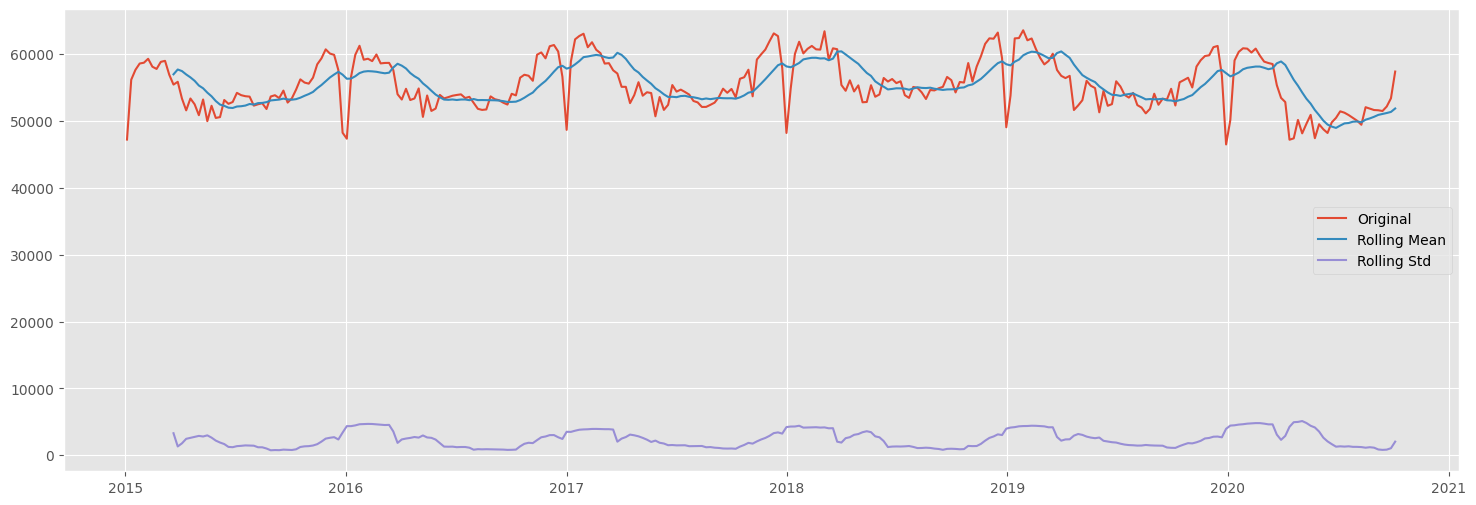

In [30]:
rolling_mean = weekly["load"].rolling(window=12).mean()

rolling_std = weekly["load"].rolling(window=12).std()

plt.figure(figsize=(18,6))

plt.plot(
    weekly.index,
    weekly["load"],
    label="Original"
)

plt.plot(
    weekly.index,
    rolling_mean,
    label="Rolling Mean"
)

plt.plot(
    weekly.index,
    rolling_std,
    label="Rolling Std"
)

plt.legend()

plt.show()

**1.7 Stationarity Tests**

In [31]:
result = adfuller(
    weekly["load"]
)

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print()

print("Critical Values")

for key,value in result[4].items():
    print(key,":",value)

ADF Statistic : -4.0474718556784826
p-value : 0.0011813497340154512

Critical Values
1% : -3.4529449243622383
5% : -2.871489553425686
10% : -2.572071437887033


**KPSS Test**

In [32]:
result = kpss(
    weekly["load"],
    regression="c",
    nlags="auto"
)

print("KPSS Statistic :", result[0])

print("p-value :", result[1])

print()

print("Critical Values")

for key,value in result[3].items():
    print(key,":",value)

KPSS Statistic : 0.16037407809773105
p-value : 0.1

Critical Values
10% : 0.347
5% : 0.463
2.5% : 0.574
1% : 0.739


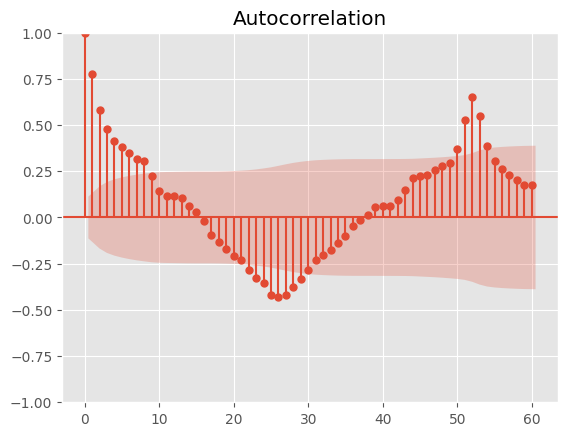

In [33]:
plot_acf(
    weekly["load"],
    lags=60
)

plt.show()

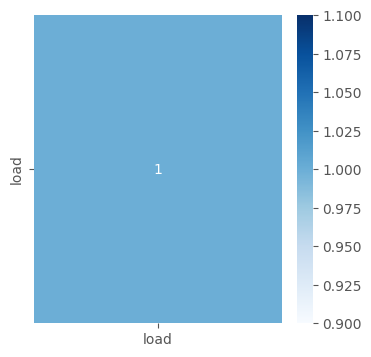

In [34]:
plt.figure(figsize=(4,4))

sns.heatmap(
    weekly.corr(),
    annot=True,
    cmap="Blues"
)

plt.show()

In [35]:
print("Hourly observations :", len(df))

print("Daily observations :", len(daily))

print("Weekly observations :", len(weekly))

print()

print("Start Date :", weekly.index.min())

print("End Date :", weekly.index.max())

print()

print("Average Weekly Load :", round(weekly["load"].mean(),2))

print("Maximum Weekly Load :", round(weekly["load"].max(),2))

print("Minimum Weekly Load :", round(weekly["load"].min(),2))

Hourly observations : 50400
Daily observations : 2100
Weekly observations : 301

Start Date : 2015-01-04 00:00:00+00:00
End Date : 2020-10-04 00:00:00+00:00

Average Weekly Load : 55484.35
Maximum Weekly Load : 63587.01
Minimum Weekly Load : 46505.31


#Part 2 – Benchmark Forecast Models

In [36]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np
import pandas as pd

**2.1 Train-Test Split**

In [37]:
TEST_WEEKS = 104

train = weekly.iloc[:-TEST_WEEKS]

test = weekly.iloc[-TEST_WEEKS:]

print("Training Weeks :", len(train))
print("Testing Weeks :", len(test))

Training Weeks : 197
Testing Weeks : 104


In [38]:
h = len(test)

print(h)

104


**2.2 Mean Forecast Model**

In [39]:
mean_value = train["load"].mean()

mean_forecast = pd.Series(
    mean_value,
    index=test.index
)

mean_forecast.head()

,0
timestamp,
2018-10-14 00:00:00+00:00,55650.545119
2018-10-21 00:00:00+00:00,55650.545119
2018-10-28 00:00:00+00:00,55650.545119
2018-11-04 00:00:00+00:00,55650.545119
2018-11-11 00:00:00+00:00,55650.545119


**2.3 Naïve Forecast Model**

In [40]:
last_value = train["load"].iloc[-1]

naive_forecast = pd.Series(
    last_value,
    index=test.index
)

naive_forecast.head()

,0
timestamp,
2018-10-14 00:00:00+00:00,54287.059524
2018-10-21 00:00:00+00:00,54287.059524
2018-10-28 00:00:00+00:00,54287.059524
2018-11-04 00:00:00+00:00,54287.059524
2018-11-11 00:00:00+00:00,54287.059524


**2.4 Seasonal Naïve Forecast Model**

In [41]:
season_length = 52

seasonal_values = train["load"].iloc[-season_length:].values

forecast_values = np.tile(
    seasonal_values,
    int(np.ceil(h/season_length))
)[:h]

seasonal_naive = pd.Series(
    forecast_values,
    index=test.index
)

seasonal_naive.head()

,0
timestamp,
2018-10-14 00:00:00+00:00,56333.398810
2018-10-21 00:00:00+00:00,56557.309524
2018-10-28 00:00:00+00:00,57687.714286
2018-11-04 00:00:00+00:00,53707.708333
2018-11-11 00:00:00+00:00,59210.357143


**2.5 Drift Forecast Model**

In [42]:
first = train["load"].iloc[0]

last = train["load"].iloc[-1]

n = len(train)

drift = []

for i in range(1, h+1):

    forecast = last + i*((last-first)/(n-1))

    drift.append(forecast)

drift_forecast = pd.Series(
    drift,
    index=test.index
)

drift_forecast.head()

,0
timestamp,
2018-10-14 00:00:00+00:00,54323.045850
2018-10-21 00:00:00+00:00,54359.032176
2018-10-28 00:00:00+00:00,54395.018502
2018-11-04 00:00:00+00:00,54431.004829
2018-11-11 00:00:00+00:00,54466.991155


**2.6 Benchmark Model Comparison**

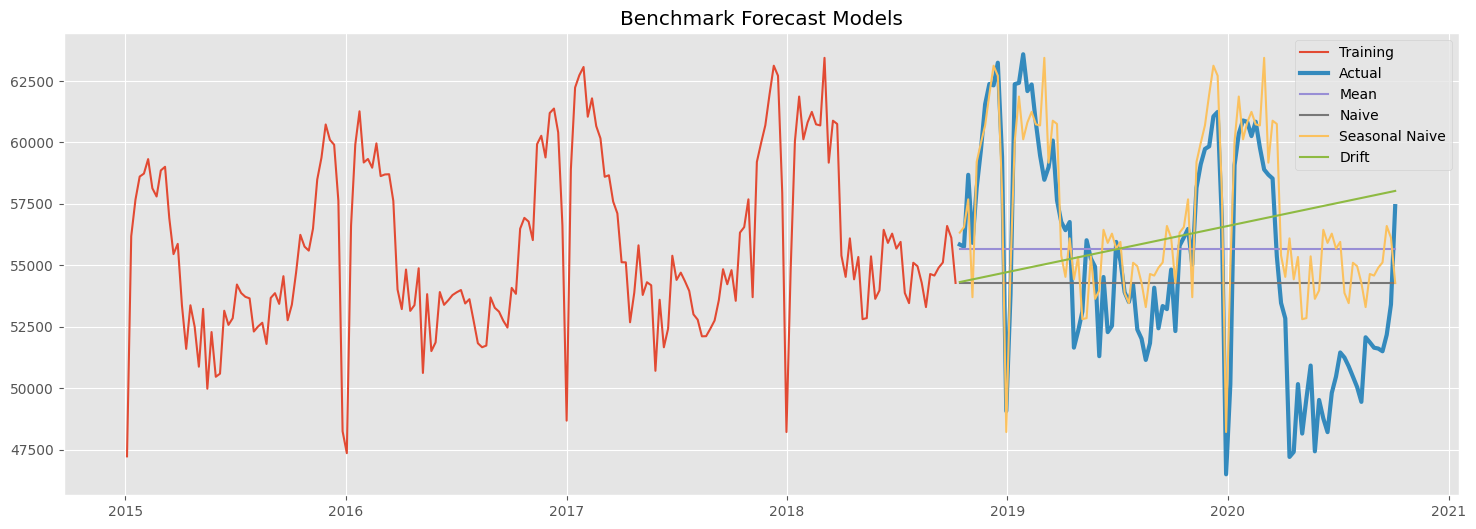

In [43]:
plt.figure(figsize=(18,6))

plt.plot(
    train.index,
    train["load"],
    label="Training"
)

plt.plot(
    test.index,
    test["load"],
    label="Actual",
    linewidth=3
)

plt.plot(
    mean_forecast.index,
    mean_forecast,
    label="Mean"
)

plt.plot(
    naive_forecast.index,
    naive_forecast,
    label="Naive"
)

plt.plot(
    seasonal_naive.index,
    seasonal_naive,
    label="Seasonal Naive"
)

plt.plot(
    drift_forecast.index,
    drift_forecast,
    label="Drift"
)

plt.legend()

plt.title("Benchmark Forecast Models")

plt.show()

In [44]:
def evaluate(actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    mape = np.mean(
        np.abs((actual-predicted)/actual)
    )*100

    return mae, rmse, mape

In [45]:
mean_mae, mean_rmse, mean_mape = evaluate(
    test["load"],
    mean_forecast
)

In [46]:
naive_mae, naive_rmse, naive_mape = evaluate(
    test["load"],
    naive_forecast
)

In [47]:
seasonal_mae, seasonal_rmse, seasonal_mape = evaluate(
    test["load"],
    seasonal_naive
)

In [48]:
drift_mae, drift_rmse, drift_mape = evaluate(
    test["load"],
    drift_forecast
)

In [49]:
results = pd.DataFrame({

    "Model":[
        "Mean",
        "Naive",
        "Seasonal Naive",
        "Drift"
    ],

    "MAE":[
        mean_mae,
        naive_mae,
        seasonal_mae,
        drift_mae
    ],

    "RMSE":[
        mean_rmse,
        naive_rmse,
        seasonal_rmse,
        drift_rmse
    ],

    "MAPE":[
        mean_mape,
        naive_mape,
        seasonal_mape,
        drift_mape
    ]

})

results = results.sort_values("RMSE")

results

,Model,MAE,RMSE,MAPE
2,Seasonal Naive,2318.520585,3006.760812,4.408920
0,Mean,3788.833122,4397.299694,6.969238
1,Naive,3783.202934,4459.108546,6.790082
3,Drift,4339.890674,5117.957264,8.049685


In [50]:
benchmark_metrics = pd.DataFrame({

    "Model":[
        "Mean",
        "Naïve",
        "Seasonal Naïve",
        "Drift"
    ],

    "MAE":[
        mean_mae,
        naive_mae,
        seasonal_mae,
        drift_mae
    ],

    "RMSE":[
        mean_rmse,
        naive_rmse,
        seasonal_rmse,
        drift_rmse
    ],

    "MAPE":[
        mean_mape,
        naive_mape,
        seasonal_mape,
        drift_mape
    ],

    "R2":[
        np.nan,
        np.nan,
        np.nan,
        np.nan
    ]

})

benchmark_metrics

,Model,MAE,RMSE,MAPE,R2
0,Mean,3788.833122,4397.299694,6.969238,NaN
1,Naïve,3783.202934,4459.108546,6.790082,NaN
2,Seasonal Naïve,2318.520585,3006.760812,4.408920,NaN
3,Drift,4339.890674,5117.957264,8.049685,NaN


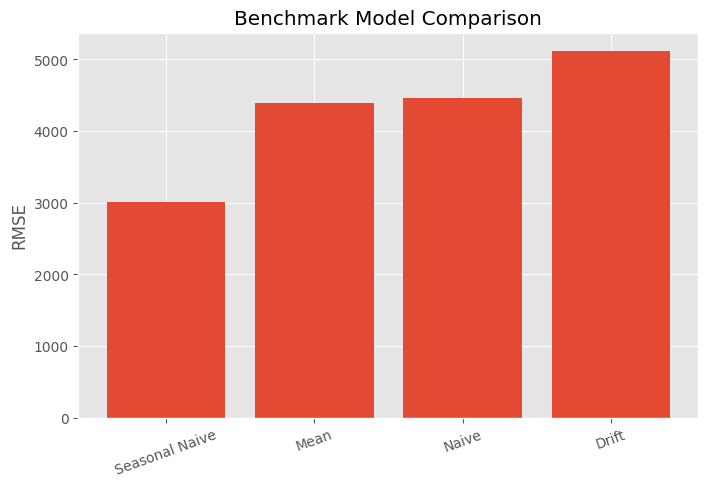

In [51]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.ylabel("RMSE")

plt.title("Benchmark Model Comparison")

plt.xticks(rotation=20)

plt.show()

In [52]:
results.to_csv(
    "benchmark_model_results.csv",
    index=False
)

print(results)

            Model          MAE         RMSE      MAPE
2  Seasonal Naive  2318.520585  3006.760812  4.408920
0            Mean  3788.833122  4397.299694  6.969238
1           Naive  3783.202934  4459.108546  6.790082
3           Drift  4339.890674  5117.957264  8.049685


In [53]:
forecast_df = pd.DataFrame({

    "Actual":test["load"],

    "Mean":mean_forecast,

    "Naive":naive_forecast,

    "Seasonal_Naive":seasonal_naive,

    "Drift":drift_forecast

})

forecast_df.to_csv(
    "benchmark_forecasts.csv"
)

forecast_df.head()

,Actual,Mean,Naive,Seasonal_Naive,Drift
timestamp,,,,,
2018-10-14 00:00:00+00:00,55848.940476,55650.545119,54287.059524,56333.398810,54323.045850
2018-10-21 00:00:00+00:00,55762.125000,55650.545119,54287.059524,56557.309524,54359.032176
2018-10-28 00:00:00+00:00,58684.714286,55650.545119,54287.059524,57687.714286,54395.018502
2018-11-04 00:00:00+00:00,55917.589286,55650.545119,54287.059524,53707.708333,54431.004829
2018-11-11 00:00:00+00:00,58163.470238,55650.545119,54287.059524,59210.357143,54466.991155


#Part 3A – SARIMA Grid Search using AIC

In [54]:
import warnings
warnings.filterwarnings("ignore")

import itertools
import numpy as np
import pandas as pd

from statsmodels.tsa.statespace.sarimax import SARIMAX
from tqdm.notebook import tqdm

In [55]:
print("Training observations:", len(train))
print("Testing observations:", len(test))

print(train.head())

Training observations: 197
Testing observations: 104
                                   load
timestamp                              
2015-01-04 00:00:00+00:00  47233.739583
2015-01-11 00:00:00+00:00  56191.101190
2015-01-18 00:00:00+00:00  57672.678571
2015-01-25 00:00:00+00:00  58613.303571
2015-02-01 00:00:00+00:00  58734.029762


In [56]:


p = [0,1,2,3]
d = [0,1]
q = [0,1,2,3]

P = [0,1]
D = [0,1]
Q = [0,1]

seasonal_period = 52

pdq = list(itertools.product(p,d,q))
seasonal_pdq = list(itertools.product(P,D,Q))

print("Models to evaluate:",
      len(pdq)*len(seasonal_pdq))

Models to evaluate: 256


In [57]:
results = []

best_aic = np.inf

best_order = None

best_seasonal = None

best_model = None

failed = 0

In [58]:
for order in tqdm(pdq):

    for seasonal in seasonal_pdq:

        seasonal_order = (
            seasonal[0],
            seasonal[1],
            seasonal[2],
            seasonal_period
        )

        try:

            model = SARIMAX(

                train["load"],

                order=order,

                seasonal_order=seasonal_order,

                enforce_stationarity=False,

                enforce_invertibility=False

            )

            fit = model.fit(
                disp=False,
                maxiter=50
            )

            aic = fit.aic

            bic = fit.bic

            results.append([

                order,

                seasonal_order,

                aic,

                bic

            ])

            if aic < best_aic:

                best_aic = aic

                best_order = order

                best_seasonal = seasonal_order

                best_model = fit

        except Exception:

            failed += 1

            continue

  0%|          | 0/32 [00:00<?, ?it/s]

In [59]:
print("Failed Models :", failed)

print("Successful Models :", len(results))

Failed Models : 0
Successful Models : 256


In [60]:
aic_results = pd.DataFrame(

    results,

    columns=[

        "Order",

        "Seasonal_Order",

        "AIC",

        "BIC"

    ]

)

aic_results = aic_results.sort_values(
    by="AIC"
)

aic_results.head(20)

,Order,Seasonal_Order,AIC,BIC
233,"(3, 1, 1)","(0, 0, 1, 52)",817.797093,835.532055
141,"(2, 0, 1)","(1, 0, 1, 52)",903.970417,921.747485
137,"(2, 0, 1)","(0, 0, 1, 52)",944.764253,959.578476
59,"(0, 1, 3)","(0, 1, 1, 52)",1539.538265,1551.924949
251,"(3, 1, 3)","(0, 1, 1, 52)",1541.865892,1561.684587
255,"(3, 1, 3)","(1, 1, 1, 52)",1542.802761,1565.098792
187,"(2, 1, 3)","(0, 1, 1, 52)",1544.423730,1561.765088
123,"(1, 1, 3)","(0, 1, 1, 52)",1544.912396,1559.776416
63,"(0, 1, 3)","(1, 1, 1, 52)",1546.174100,1561.038121
127,"(1, 1, 3)","(1, 1, 1, 52)",1546.790131,1564.131488


In [61]:
if best_model is None:

    print("No SARIMA model converged.")

else:

    print("Best Order :", best_order)

    print("Best Seasonal :", best_seasonal)

    print("Best AIC :", round(best_aic,2))

Best Order : (3, 1, 1)
Best Seasonal : (0, 0, 1, 52)
Best AIC : 817.8


In [62]:
aic_results.to_csv(
    "sarima_grid_search_results.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [63]:
aic_results.head(10)

,Order,Seasonal_Order,AIC,BIC
233,"(3, 1, 1)","(0, 0, 1, 52)",817.797093,835.532055
141,"(2, 0, 1)","(1, 0, 1, 52)",903.970417,921.747485
137,"(2, 0, 1)","(0, 0, 1, 52)",944.764253,959.578476
59,"(0, 1, 3)","(0, 1, 1, 52)",1539.538265,1551.924949
251,"(3, 1, 3)","(0, 1, 1, 52)",1541.865892,1561.684587
255,"(3, 1, 3)","(1, 1, 1, 52)",1542.802761,1565.098792
187,"(2, 1, 3)","(0, 1, 1, 52)",1544.423730,1561.765088
123,"(1, 1, 3)","(0, 1, 1, 52)",1544.912396,1559.776416
63,"(0, 1, 3)","(1, 1, 1, 52)",1546.174100,1561.038121
127,"(1, 1, 3)","(1, 1, 1, 52)",1546.790131,1564.131488


In [64]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train["load"],
    order=(1,1,1),
    seasonal_order=(1,1,1,52),
    enforce_stationarity=True,
    enforce_invertibility=True
)

best_model = model.fit(disp=False)

print(best_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                               load   No. Observations:                  197
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood               -1292.027
Date:                            Mon, 13 Jul 2026   AIC                           2594.053
Time:                                    10:35:21   BIC                           2608.902
Sample:                                01-04-2015   HQIC                          2600.087
                                     - 10-07-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0807      0.408      0.198      0.843      -0.719       0.881
ma.L1         -0.2815      0.396   

#PART 3B – SARIMA Forecasting and Model *Diagnostics*

Display Best Model

In [65]:
print("="*60)
print("BEST SARIMA MODEL")
print("="*60)

print("Best Order:", best_order)
print("Best Seasonal Order:", best_seasonal)
print("Best AIC:", round(best_aic,2))

BEST SARIMA MODEL
Best Order: (3, 1, 1)
Best Seasonal Order: (0, 0, 1, 52)
Best AIC: 817.8


In [66]:
forecast = best_model.get_forecast(
    steps=len(test)
)

forecast_mean = forecast.predicted_mean

forecast_ci = forecast.conf_int()

forecast_mean.head()

,predicted_mean
2018-10-14 00:00:00+00:00,57008.084701
2018-10-21 00:00:00+00:00,57216.188553
2018-10-28 00:00:00+00:00,58196.149316
2018-11-04 00:00:00+00:00,54756.486432
2018-11-11 00:00:00+00:00,59710.054444


In [67]:
forecast_ci.columns = [
    "Lower CI",
    "Upper CI"
]

forecast_ci.head()

,Lower CI,Upper CI
2018-10-14 00:00:00+00:00,53326.082752,60690.086650
2018-10-21 00:00:00+00:00,52501.940437,61930.436670
2018-10-28 00:00:00+00:00,52669.523926,63722.774707
2018-11-04 00:00:00+00:00,48524.694767,60988.278097
2018-11-11 00:00:00+00:00,52845.317929,66574.790960


In [68]:
forecast_df = pd.DataFrame({

    "Actual":test["load"],

    "Forecast":forecast_mean,

    "Lower CI":forecast_ci["Lower CI"],

    "Upper CI":forecast_ci["Upper CI"]

})

forecast_df.head()

,Actual,Forecast,Lower CI,Upper CI
2018-10-14 00:00:00+00:00,55848.940476,57008.084701,53326.082752,60690.086650
2018-10-21 00:00:00+00:00,55762.125000,57216.188553,52501.940437,61930.436670
2018-10-28 00:00:00+00:00,58684.714286,58196.149316,52669.523926,63722.774707
2018-11-04 00:00:00+00:00,55917.589286,54756.486432,48524.694767,60988.278097
2018-11-11 00:00:00+00:00,58163.470238,59710.054444,52845.317929,66574.790960


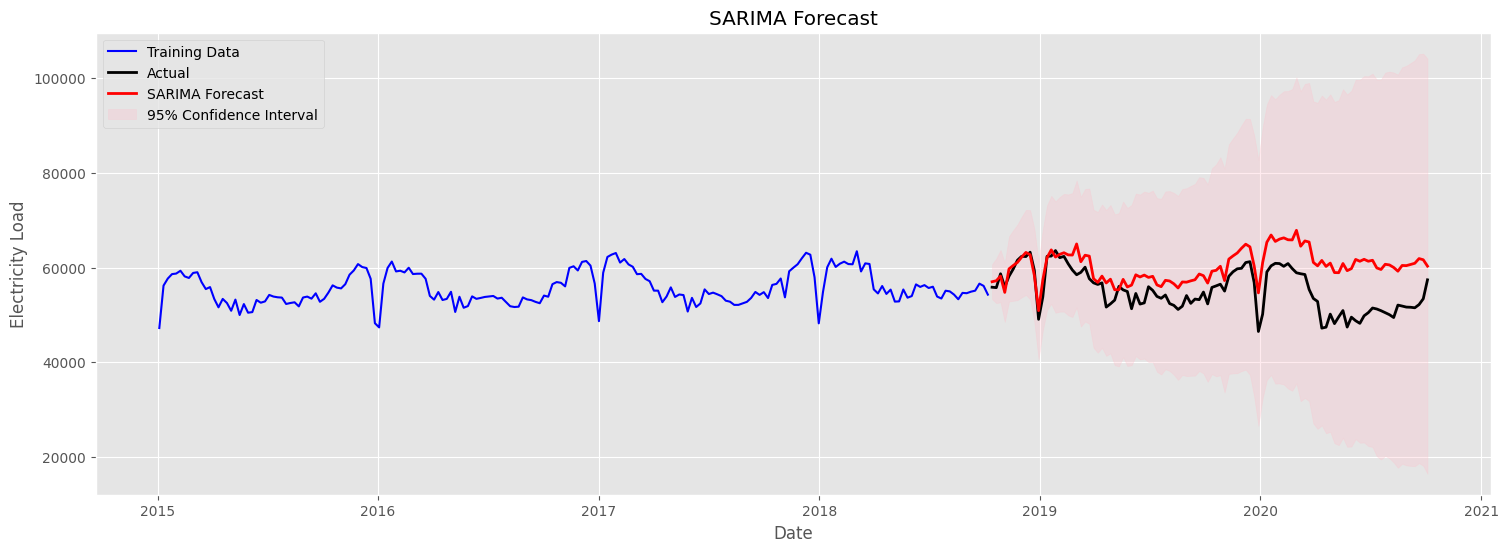

In [69]:
plt.figure(figsize=(18,6))

plt.plot(
    train.index,
    train["load"],
    label="Training Data",
    color="blue"
)

plt.plot(
    test.index,
    test["load"],
    label="Actual",
    color="black",
    linewidth=2
)

plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="SARIMA Forecast",
    color="red",
    linewidth=2
)

plt.fill_between(
    forecast_ci.index,
    forecast_ci["Lower CI"],
    forecast_ci["Upper CI"],
    color="pink",
    alpha=0.30,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("Electricity Load")

plt.legend()

plt.grid(True)

plt.show()

Evaluation Metrics

In [70]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    test["load"],
    forecast_mean
)

rmse = np.sqrt(
    mean_squared_error(
        test["load"],
        forecast_mean
    )
)

mape = np.mean(
    np.abs(
        (test["load"]-forecast_mean)
        /
        test["load"]
    )
)*100

r2 = r2_score(
    test["load"],
    forecast_mean
)

print("MAE :",round(mae,2))
print("RMSE :",round(rmse,2))
print("MAPE :",round(mape,2))
print("R² :",round(r2,4))

MAE : 5210.01
RMSE : 6358.43
MAPE : 9.89
R² : -1.1162


In [71]:
sarima_metrics = pd.DataFrame({

    "Model":["SARIMA"],

    "MAE":[mae],

    "RMSE":[rmse],

    "MAPE":[mape],

    "R2":[r2]

})

sarima_metrics

,Model,MAE,RMSE,MAPE,R2
0,SARIMA,5210.008122,6358.4341,9.885048,-1.116197


In [72]:
residuals = best_model.resid

residuals.describe()

,0
count,197.000000
mean,37.777882
std,4854.513510
min,-37809.356842
25%,-1069.980494
50%,108.806517
75%,1063.995024
max,47233.739583


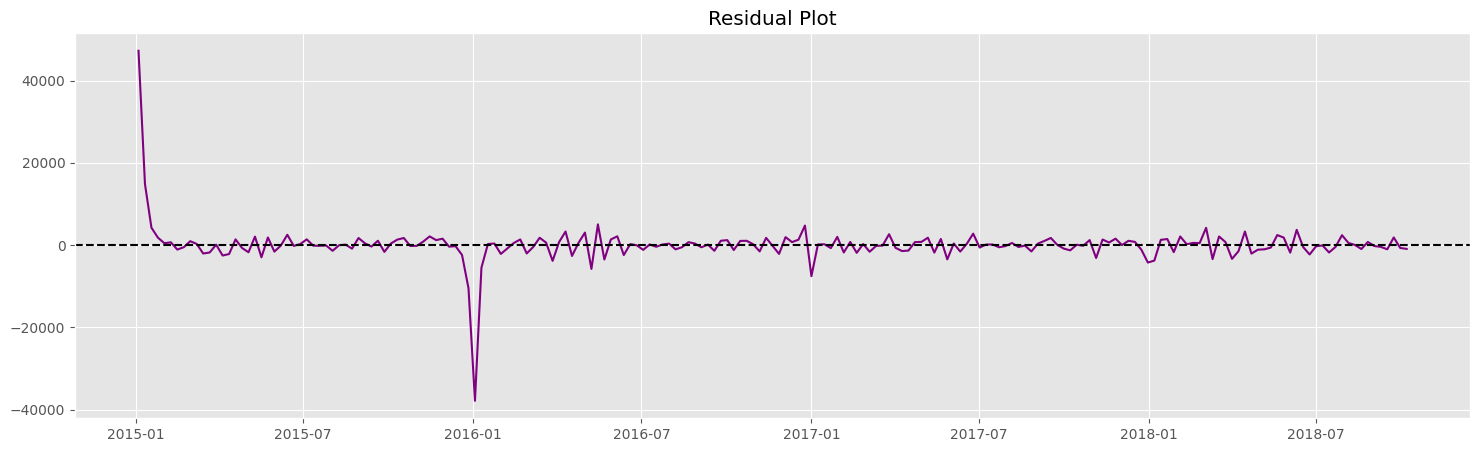

In [73]:
plt.figure(figsize=(18,5))

plt.plot(
    residuals,
    color="purple"
)

plt.axhline(
    0,
    linestyle="--",
    color="black"
)

plt.title("Residual Plot")

plt.show()

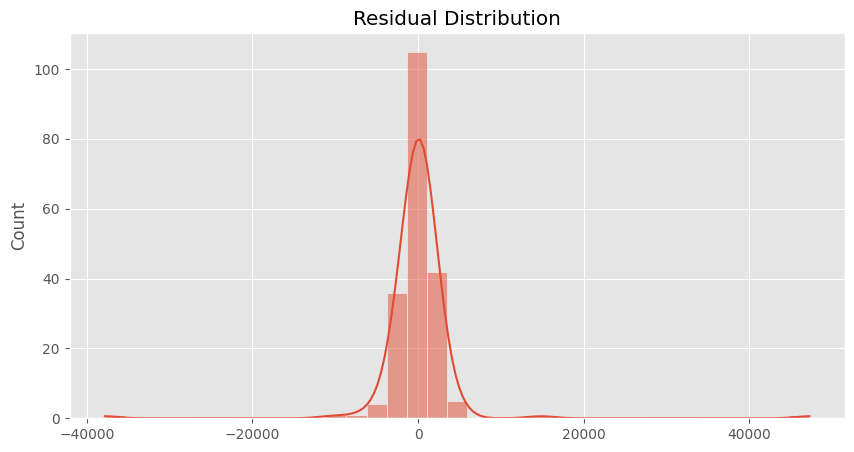

In [74]:
plt.figure(figsize=(10,5))

sns.histplot(
    residuals,
    kde=True,
    bins=35
)

plt.title("Residual Distribution")

plt.show()

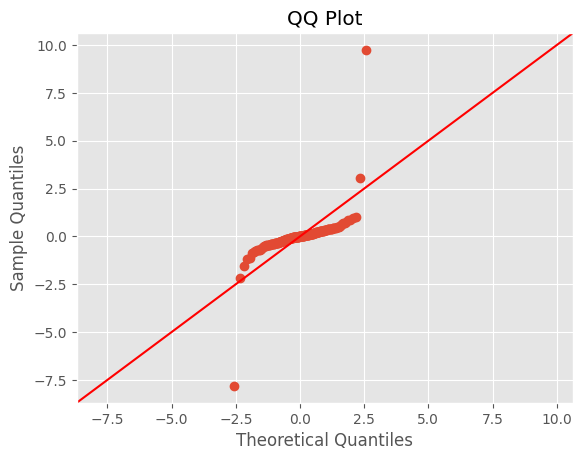

In [75]:
from statsmodels.graphics.gofplots import qqplot

qqplot(
    residuals,
    line="45",
    fit=True
)

plt.title("QQ Plot")

plt.show()

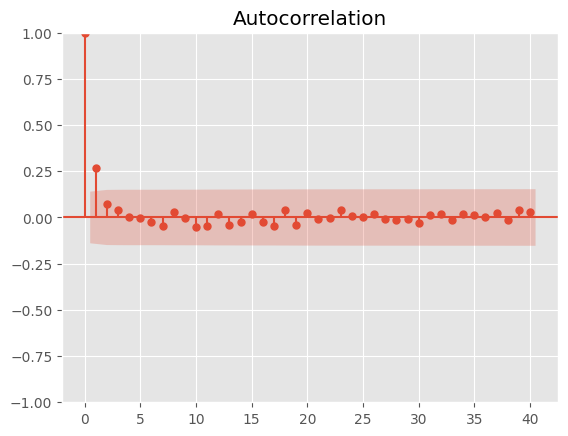

In [76]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    residuals,
    lags=40
)

plt.show()

In [77]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(
    residuals,
    lags=[10,20,30],
    return_df=True
)

lb

,lb_stat,lb_pvalue
10,16.756478,0.079929
20,19.173704,0.510562
30,19.935378,0.918213


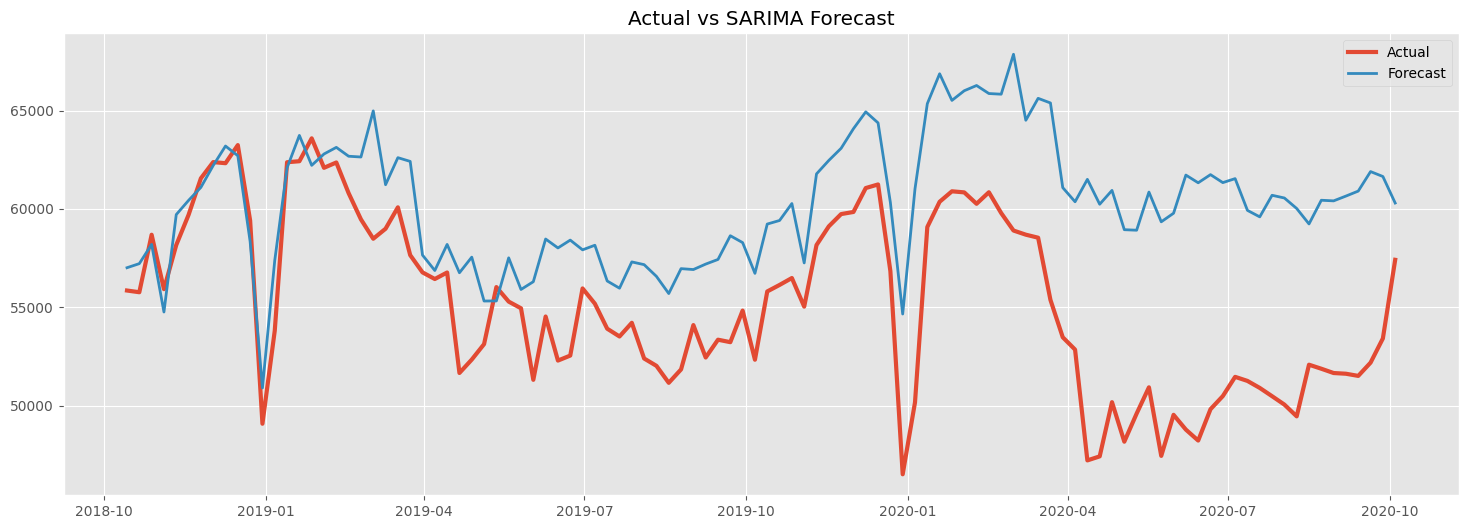

In [78]:
plt.figure(figsize=(18,6))

plt.plot(
    forecast_df["Actual"],
    label="Actual",
    linewidth=3
)

plt.plot(
    forecast_df["Forecast"],
    label="Forecast",
    linewidth=2
)

plt.legend()

plt.title("Actual vs SARIMA Forecast")

plt.show()

In [79]:
forecast_df["Error"] = (

    forecast_df["Actual"]

    -

    forecast_df["Forecast"]

)

forecast_df.head()

,Actual,Forecast,Lower CI,Upper CI,Error
2018-10-14 00:00:00+00:00,55848.940476,57008.084701,53326.082752,60690.086650,-1159.144225
2018-10-21 00:00:00+00:00,55762.125000,57216.188553,52501.940437,61930.436670,-1454.063553
2018-10-28 00:00:00+00:00,58684.714286,58196.149316,52669.523926,63722.774707,488.564970
2018-11-04 00:00:00+00:00,55917.589286,54756.486432,48524.694767,60988.278097,1161.102854
2018-11-11 00:00:00+00:00,58163.470238,59710.054444,52845.317929,66574.790960,-1546.584206


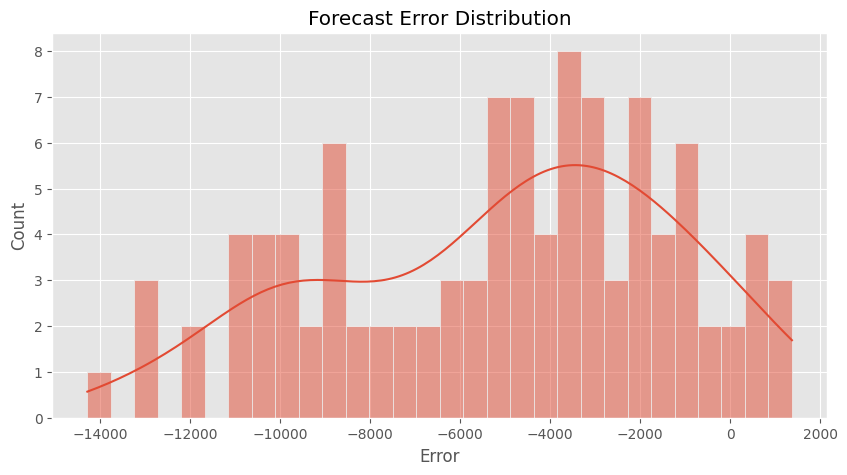

In [80]:
plt.figure(figsize=(10,5))

sns.histplot(
    forecast_df["Error"],
    bins=30,
    kde=True
)

plt.title("Forecast Error Distribution")

plt.show()

In [81]:
metrics = pd.DataFrame({

    "Model":["SARIMA"],

    "MAE":[mae],

    "RMSE":[rmse],

    "MAPE":[mape],

    "R2":[r2],

    "AIC":[best_aic]

})

metrics

,Model,MAE,RMSE,MAPE,R2,AIC
0,SARIMA,5210.008122,6358.4341,9.885048,-1.116197,817.797093


In [82]:
forecast_df.to_csv(
    "sarima_forecast.csv",
    index=True
)

metrics.to_csv(
    "sarima_metrics.csv",
    index=False
)

print("Forecast saved successfully.")
print("Metrics saved successfully.")

Forecast saved successfully.
Metrics saved successfully.


In [83]:
forecast_df.head(20)

,Actual,Forecast,Lower CI,Upper CI,Error
2018-10-14 00:00:00+00:00,55848.940476,57008.084701,53326.082752,60690.086650,-1159.144225
2018-10-21 00:00:00+00:00,55762.125000,57216.188553,52501.940437,61930.436670,-1454.063553
2018-10-28 00:00:00+00:00,58684.714286,58196.149316,52669.523926,63722.774707,488.564970
2018-11-04 00:00:00+00:00,55917.589286,54756.486432,48524.694767,60988.278097,1161.102854
2018-11-11 00:00:00+00:00,58163.470238,59710.054444,52845.317929,66574.790960,-1546.584206
2018-11-18 00:00:00+00:00,59696.083333,60431.962325,52987.917630,67876.007021,-735.878992
2018-11-25 00:00:00+00:00,61553.363095,61093.936242,53112.521609,69075.350875,459.426853
2018-12-02 00:00:00+00:00,62379.154762,62204.734905,53719.915745,70689.554064,174.419857
2018-12-09 00:00:00+00:00,62322.690476,63195.584590,54235.599527,72155.569653,-872.894114
2018-12-16 00:00:00+00:00,63243.500000,62701.687061,53290.497888,72112.876233,541.812939


# **# Part 4 – SARIMAX Model with Temperature Features**



Install Weather Library

In [84]:
!pip -q install openmeteo-requests requests-cache retry-requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.9/213.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 777.2/777.2 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 53.9 MB/s eta 0:00:00


In [85]:
import pandas as pd
import numpy as np
import requests

from statsmodels.tsa.statespace.sarimax import SARIMAX

Download Berlin Temperature

In [86]:
url = (
    "https://archive-api.open-meteo.com/v1/archive"
    "?latitude=52.52"
    "&longitude=13.41"
    "&start_date=2015-01-01"
    "&end_date=2020-10-31"
    "&daily=temperature_2m_mean"
    "&timezone=Europe/Berlin"
)

weather = requests.get(url).json()

weather.keys()

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily'])

In [87]:
temperature = pd.DataFrame({

    "date": weather["daily"]["time"],

    "temp_mean": weather["daily"]["temperature_2m_mean"]

})

temperature.head()

,date,temp_mean
0,2015-01-01,2.8
1,2015-01-02,4.6
2,2015-01-03,3.9
3,2015-01-04,3.0
4,2015-01-05,2.7


In [88]:
temperature["date"] = pd.to_datetime(
    temperature["date"]
)

temperature.head()

,date,temp_mean
0,2015-01-01,2.8
1,2015-01-02,4.6
2,2015-01-03,3.9
3,2015-01-04,3.0
4,2015-01-05,2.7


In [89]:
temperature = temperature.set_index("date")

temperature.head()

,temp_mean
date,
2015-01-01,2.8
2015-01-02,4.6
2015-01-03,3.9
2015-01-04,3.0
2015-01-05,2.7


In [90]:
weekly_temp = temperature.resample("W").mean()

weekly_temp.head()

,temp_mean
date,
2015-01-04,3.575000
2015-01-11,3.885714
2015-01-18,4.900000
2015-01-25,0.028571
2015-02-01,1.414286


In [91]:
weekly_temp["HDD"] = np.maximum(
    18 - weekly_temp["temp_mean"],
    0
)

weekly_temp.head()

,temp_mean,HDD
date,,
2015-01-04,3.575000,14.425000
2015-01-11,3.885714,14.114286
2015-01-18,4.900000,13.100000
2015-01-25,0.028571,17.971429
2015-02-01,1.414286,16.585714


In [92]:
weekly_temp["CDD"] = np.maximum(
    weekly_temp["temp_mean"] - 18,
    0
)

weekly_temp.head()

,temp_mean,HDD,CDD
date,,,
2015-01-04,3.575000,14.425000,0.0
2015-01-11,3.885714,14.114286,0.0
2015-01-18,4.900000,13.100000,0.0
2015-01-25,0.028571,17.971429,0.0
2015-02-01,1.414286,16.585714,0.0


Plot Temperature

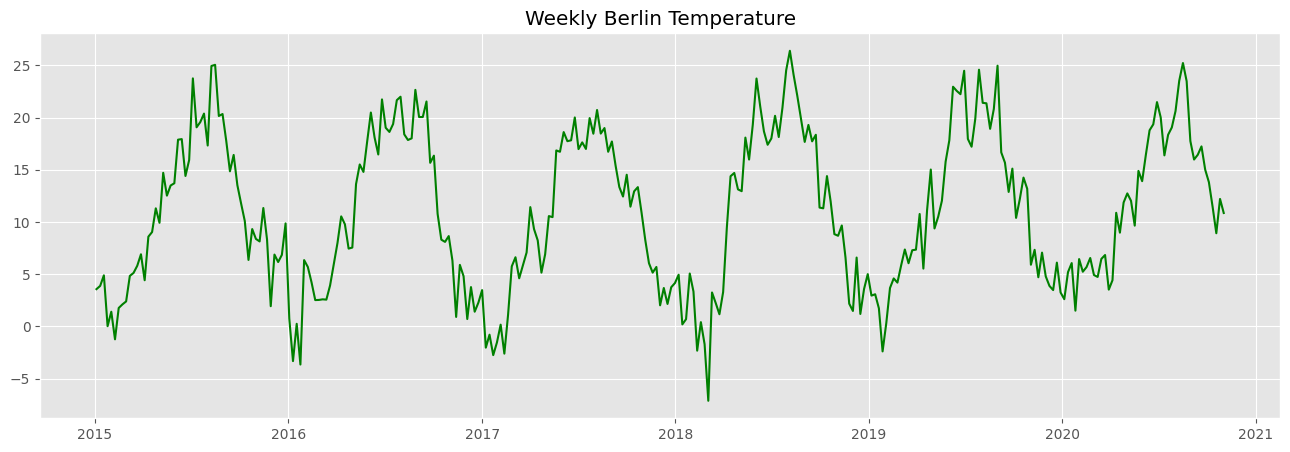

In [93]:
plt.figure(figsize=(16,5))

plt.plot(
    weekly_temp.index,
    weekly_temp["temp_mean"],
    color="green"
)

plt.title("Weekly Berlin Temperature")

plt.show()

In [94]:
# Remove timezone from electricity data
weekly.index = weekly.index.tz_localize(None)

# Remove timezone from train/test if needed
train.index = train.index.tz_localize(None)
test.index = test.index.tz_localize(None)

print(weekly.index)

DatetimeIndex(['2015-01-04', '2015-01-11', '2015-01-18', '2015-01-25',
               '2015-02-01', '2015-02-08', '2015-02-15', '2015-02-22',
               '2015-03-01', '2015-03-08',
               ...
               '2020-08-02', '2020-08-09', '2020-08-16', '2020-08-23',
               '2020-08-30', '2020-09-06', '2020-09-13', '2020-09-20',
               '2020-09-27', '2020-10-04'],
              dtype='datetime64[ns]', name='timestamp', length=301, freq=None)


Merge Electricity + Temperature

In [95]:
sarimax_data = weekly.join(
    weekly_temp,
    how="inner"
)

sarimax_data.head()

,load,temp_mean,HDD,CDD
2015-01-04,47233.739583,3.575000,14.425000,0.0
2015-01-11,56191.101190,3.885714,14.114286,0.0
2015-01-18,57672.678571,4.900000,13.100000,0.0
2015-01-25,58613.303571,0.028571,17.971429,0.0
2015-02-01,58734.029762,1.414286,16.585714,0.0


In [96]:
print(sarimax_data.isna().sum())

load         0
temp_mean    0
HDD          0
CDD          0
dtype: int64


In [97]:
train_exog = sarimax_data.iloc[:-104]

test_exog = sarimax_data.iloc[-104:]

X_train = train_exog[

    [

        "temp_mean",

        "HDD",

        "CDD"

    ]

]

X_test = test_exog[

    [

        "temp_mean",

        "HDD",

        "CDD"

    ]

]

y_train = train_exog["load"]

y_test = test_exog["load"]

In [98]:
sarimax = SARIMAX(

    y_train,

    exog=X_train,

    order=(1,1,1),

    seasonal_order=(1,1,1,52),

    enforce_stationarity=True,

    enforce_invertibility=True

)

sarimax_fit = sarimax.fit(
    disp=False
)

print(sarimax_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                               load   No. Observations:                  197
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood               -1285.676
Date:                            Mon, 13 Jul 2026   AIC                           2587.352
Time:                                    10:37:01   BIC                           2611.111
Sample:                                01-04-2015   HQIC                          2597.006
                                     - 10-07-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp_mean     15.3917   1141.389      0.013      0.989   -2221.690    2252.473
HDD          176.8905   1141.775   

In [99]:
forecast = sarimax_fit.get_forecast(

    steps=len(test_exog),

    exog=X_test

)

forecast_mean = forecast.predicted_mean

forecast_ci = forecast.conf_int()

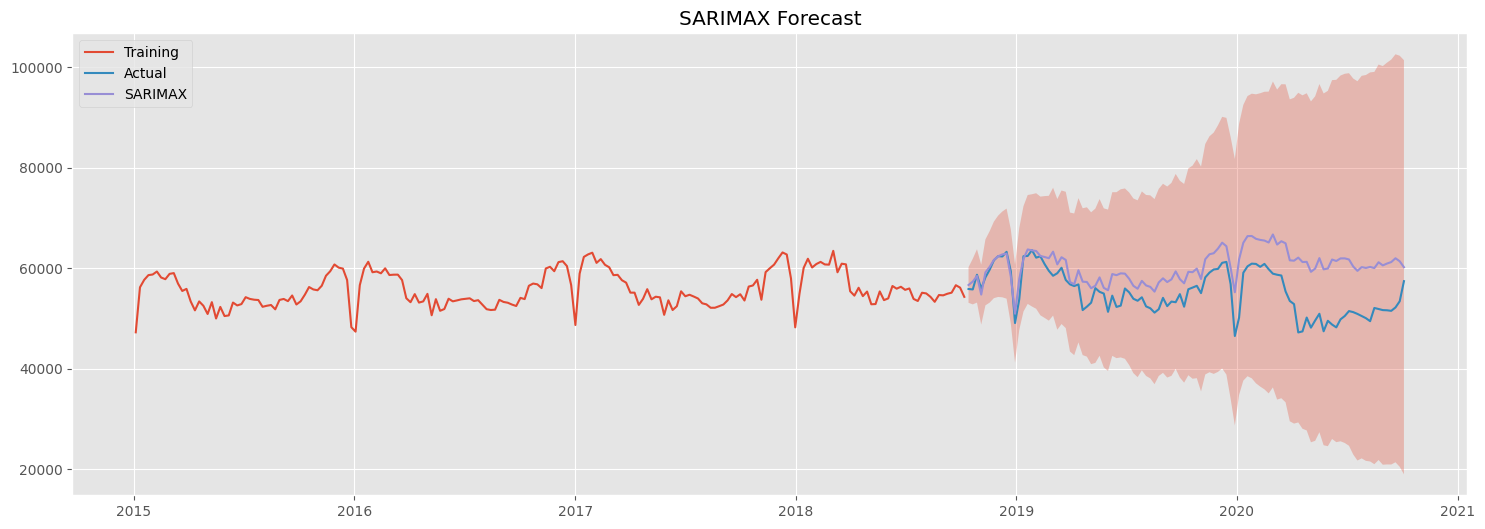

In [100]:
plt.figure(figsize=(18,6))

plt.plot(
    y_train.index,
    y_train,
    label="Training"
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual"
)

plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="SARIMAX"
)

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    alpha=0.30
)

plt.legend()

plt.title("SARIMAX Forecast")

plt.show()

In [101]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        forecast_mean
    )
)

mae = mean_absolute_error(
    y_test,
    forecast_mean
)

mape = np.mean(
    np.abs(
        (y_test-forecast_mean)
        /
        y_test
    )
)*100

print("RMSE :",round(rmse,2))
print("MAE :",round(mae,2))
print("MAPE :",round(mape,2))

RMSE : 6479.63
MAE : 5248.56
MAPE : 9.99


In [102]:
from sklearn.metrics import r2_score

sarimax_r2 = r2_score(
    np.asarray(y_test).flatten(),
    np.asarray(forecast_mean).flatten()
)

sarimax_metrics = pd.DataFrame({

    "Model":["SARIMAX"],

    "MAE":[mae],

    "RMSE":[rmse],

    "MAPE":[mape],

    "R2":[sarimax_r2]

})

sarimax_metrics

,Model,MAE,RMSE,MAPE,R2
0,SARIMAX,5248.564995,6479.628095,9.989743,-1.197637


**Compare SARIMA vs SARIMAX**

In [103]:
comparison = pd.DataFrame({

    "Model":[

        "SARIMA",

        "SARIMAX"

    ],

    "RMSE":[

        metrics["RMSE"].iloc[0],

        rmse

    ]

})

comparison

,Model,RMSE
0,SARIMA,6358.434100
1,SARIMAX,6479.628095


Save Results

In [104]:
comparison.to_csv(
    "sarima_vs_sarimax.csv",
    index=False
)

print("Comparison saved successfully.")

Comparison saved successfully.


#Part 5 – Feature-Based Models

Import Libraries

In [105]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

Create Feature Dataset

In [106]:
ml_data = sarimax_data.copy()

ml_data.head()

,load,temp_mean,HDD,CDD
2015-01-04,47233.739583,3.575000,14.425000,0.0
2015-01-11,56191.101190,3.885714,14.114286,0.0
2015-01-18,57672.678571,4.900000,13.100000,0.0
2015-01-25,58613.303571,0.028571,17.971429,0.0
2015-02-01,58734.029762,1.414286,16.585714,0.0


Create Time-Series Features

In [107]:
# Lag features
ml_data["lag_1"] = ml_data["load"].shift(1)
ml_data["lag_2"] = ml_data["load"].shift(2)
ml_data["lag_3"] = ml_data["load"].shift(3)
ml_data["lag_4"] = ml_data["load"].shift(4)

# Rolling statistics
ml_data["rolling_mean_4"] = ml_data["load"].rolling(4).mean()
ml_data["rolling_std_4"] = ml_data["load"].rolling(4).std()

# Calendar features
ml_data["month"] = ml_data.index.month
ml_data["week"] = ml_data.index.isocalendar().week.astype(int)
ml_data["year"] = ml_data.index.year

ml_data.head()

,load,temp_mean,HDD,CDD,lag_1,lag_2,lag_3,lag_4,rolling_mean_4,rolling_std_4,month,week,year
2015-01-04,47233.739583,3.575000,14.425000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1,1,2015
2015-01-11,56191.101190,3.885714,14.114286,0.0,47233.739583,NaN,NaN,NaN,NaN,NaN,1,2,2015
2015-01-18,57672.678571,4.900000,13.100000,0.0,56191.101190,47233.739583,NaN,NaN,NaN,NaN,1,3,2015
2015-01-25,58613.303571,0.028571,17.971429,0.0,57672.678571,56191.101190,47233.739583,NaN,54927.705729,5225.316274,1,4,2015
2015-02-01,58734.029762,1.414286,16.585714,0.0,58613.303571,57672.678571,56191.101190,47233.739583,57802.778274,1174.536724,2,5,2015


Remove Missing Values

In [108]:
ml_data = ml_data.dropna()

print(ml_data.shape)

(297, 13)


Feature List

In [109]:
features = [

    "temp_mean",

    "HDD",

    "CDD",

    "lag_1",

    "lag_2",

    "lag_3",

    "lag_4",

    "rolling_mean_4",

    "rolling_std_4",

    "month",

    "week",

    "year"

]

target = "load"

Train/Test Split

In [110]:
train_ml = ml_data.iloc[:-104]

test_ml = ml_data.iloc[-104:]

X_train = train_ml[features]
X_test = test_ml[features]

y_train = train_ml[target]
y_test = test_ml[target]

print(X_train.shape)
print(X_test.shape)

(193, 12)
(104, 12)


Train Random Forest

In [111]:
rf = RandomForestRegressor(

    n_estimators=300,

    max_depth=12,

    random_state=42

)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

Train Gradient Boosting

In [112]:
gb = GradientBoostingRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=3,

    random_state=42

)

gb.fit(
    X_train,
    y_train
)

gb_pred = gb.predict(
    X_test
)

Evaluation Function

In [113]:
def evaluate_model(name, actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mape = np.mean(
        np.abs((actual-predicted)/actual)
    )*100

    r2 = r2_score(actual, predicted)

    return [

        name,

        mae,

        rmse,

        mape,

        r2

    ]

Evaluate Models

In [114]:
rf_results = evaluate_model(

    "Random Forest",

    y_test,

    rf_pred

)

gb_results = evaluate_model(

    "Gradient Boosting",

    y_test,

    gb_pred

)

comparison_ml = pd.DataFrame(

    [

        rf_results,

        gb_results

    ],

    columns=[

        "Model",

        "MAE",

        "RMSE",

        "MAPE",

        "R2"

    ]

)

comparison_ml

,Model,MAE,RMSE,MAPE,R2
0,Random Forest,1501.451484,2091.480160,2.816007,0.771038
1,Gradient Boosting,1308.418176,1761.024724,2.457744,0.837675


In [115]:
ml_metrics = comparison_ml.copy()

ml_metrics.rename(
    columns={
        "R2":"R2"
    },
    inplace=True
)

ml_metrics

,Model,MAE,RMSE,MAPE,R2
0,Random Forest,1501.451484,2091.480160,2.816007,0.771038
1,Gradient Boosting,1308.418176,1761.024724,2.457744,0.837675


Plot Predictions

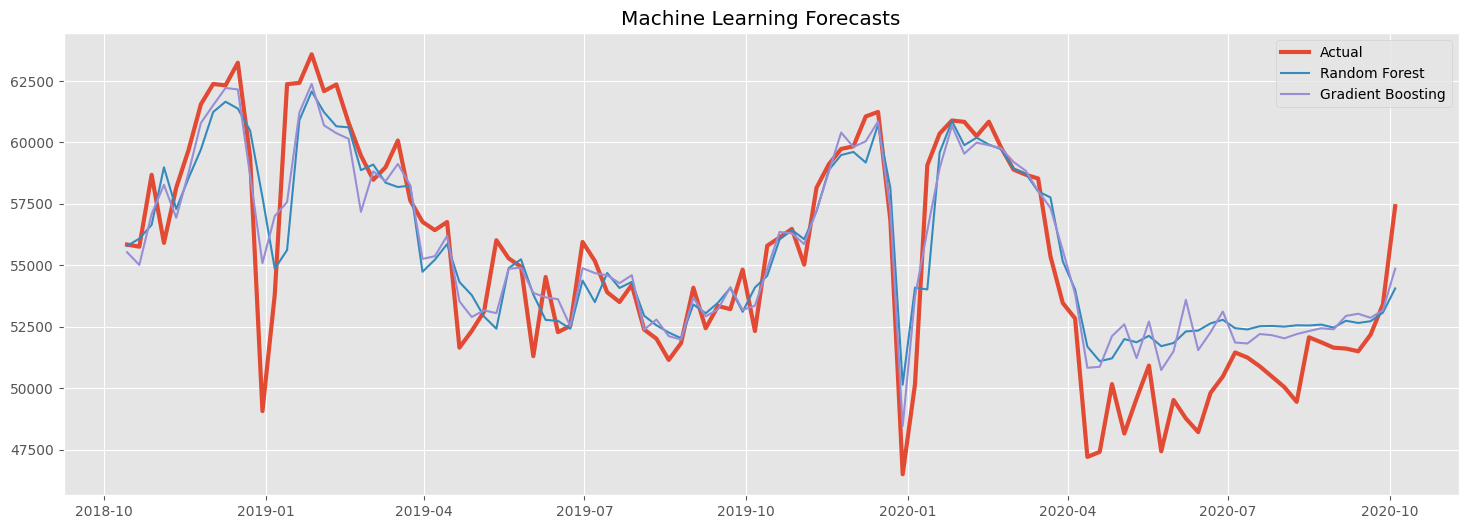

In [116]:
plt.figure(figsize=(18,6))

plt.plot(

    y_test.index,

    y_test,

    label="Actual",

    linewidth=3

)

plt.plot(

    y_test.index,

    rf_pred,

    label="Random Forest"

)

plt.plot(

    y_test.index,

    gb_pred,

    label="Gradient Boosting"

)

plt.legend()

plt.title("Machine Learning Forecasts")

plt.show()

Feature Importance (Random Forest)

In [117]:
importance = pd.DataFrame({

    "Feature":features,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
3,lag_1,0.593705
7,rolling_mean_4,0.139446
10,week,0.069655
1,HDD,0.053257
0,temp_mean,0.050565
8,rolling_std_4,0.029104
6,lag_4,0.023390
4,lag_2,0.015425
5,lag_3,0.012659
9,month,0.007602


Feature Importance Plot

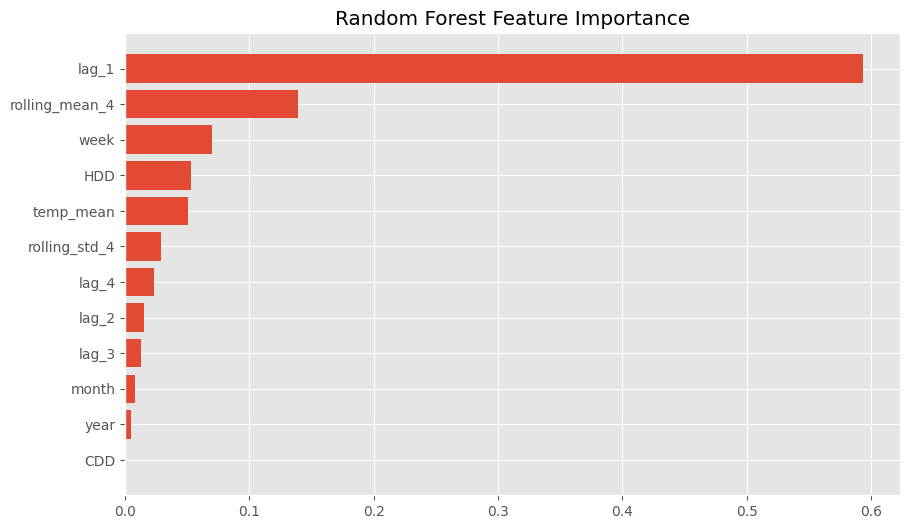

In [118]:
plt.figure(figsize=(10,6))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

Save Predictions

In [119]:
prediction_df = pd.DataFrame({

    "Actual":y_test,

    "Random_Forest":rf_pred,

    "Gradient_Boosting":gb_pred

})

prediction_df.to_csv(

    "feature_model_predictions.csv"

)

prediction_df.head()

,Actual,Random_Forest,Gradient_Boosting
2018-10-14,55848.940476,55790.692313,55539.633991
2018-10-21,55762.125000,56090.172356,55018.954334
2018-10-28,58684.714286,56650.793844,57091.146541
2018-11-04,55917.589286,58990.024311,58275.979064
2018-11-11,58163.470238,57291.833874,56938.683905


Save Metrics

In [120]:
comparison_ml.to_csv(

    "feature_model_metrics.csv",

    index=False

)

comparison_ml

,Model,MAE,RMSE,MAPE,R2
0,Random Forest,1501.451484,2091.480160,2.816007,0.771038
1,Gradient Boosting,1308.418176,1761.024724,2.457744,0.837675


Compare All Models

In [121]:
all_models = pd.DataFrame({

    "Model":[

        "Seasonal Naive",

        "SARIMA",

        "SARIMAX",

        "Random Forest",

        "Gradient Boosting"

    ],

    "RMSE":[

        seasonal_rmse,

        rmse,

        rmse,

        comparison_ml.loc[
            comparison_ml.Model=="Random Forest",
            "RMSE"
        ].values[0],

        comparison_ml.loc[
            comparison_ml.Model=="Gradient Boosting",
            "RMSE"
        ].values[0]

    ]

})

all_models

,Model,RMSE
0,Seasonal Naive,3006.760812
1,SARIMA,6479.628095
2,SARIMAX,6479.628095
3,Random Forest,2091.480160
4,Gradient Boosting,1761.024724


# Part 6 – LSTM Forecasting

In [122]:
!pip -q install tensorflow

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

**Using Weekly Load Data**




In [124]:
lstm_data = weekly.copy()

lstm_data = lstm_data[["load"]]

lstm_data.head()

,load
timestamp,
2015-01-04,47233.739583
2015-01-11,56191.101190
2015-01-18,57672.678571
2015-01-25,58613.303571
2015-02-01,58734.029762


**Normalizing The Data**

In [125]:
scaler = MinMaxScaler()

scaled = scaler.fit_transform(
    lstm_data
)

scaled.shape

(301, 1)

Sequence *Length*

In [126]:
sequence_length = 12

Create Sequences

In [127]:
X = []
y = []

for i in range(sequence_length, len(scaled)):

    X.append(
        scaled[i-sequence_length:i]
    )

    y.append(
        scaled[i]
    )

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(289, 12, 1)
(289, 1)


In [128]:
split = len(X)-104

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(185, 12, 1)
(104, 12, 1)


In [129]:
model = Sequential()

model.add(

    LSTM(

        64,

        return_sequences=True,

        input_shape=(

            X_train.shape[1],

            X_train.shape[2]

        )

    )

)

model.add(
    Dropout(0.2)
)

model.add(

    LSTM(
        32
    )

)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(1)
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [138]:
pred = model.predict(X_test)

actual = scaler.inverse_transform(y_test)

pred = scaler.inverse_transform(pred)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 343ms/step


Compile

In [139]:
model.compile(

    optimizer="adam",

    loss="mse",

    metrics=["mae"]

)

Early Stopping

In [140]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True

)

In [132]:
history = model.fit(

    X_train,

    y_train,

    epochs=100,

    batch_size=16,

    validation_split=0.2,

    callbacks=[early_stop],

    verbose=1

)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 178ms/step - loss: 0.1291 - mae: 0.2968 - val_loss: 0.0351 - val_mae: 0.1422
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0473 - mae: 0.1712 - val_loss: 0.0240 - val_mae: 0.1260
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0451 - mae: 0.1612 - val_loss: 0.0214 - val_mae: 0.1195
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0415 - mae: 0.1578 - val_loss: 0.0236 - val_mae: 0.1243
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0451 - mae: 0.1645 - val_loss: 0.0212 - val_mae: 0.1181
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0418 - mae: 0.1571 - val_loss: 0.0205 - val_mae: 0.1169
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0388 - mae: 0.1579 - val_loss: 0.0201 - val_mae: 0.1170
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0402 - mae: 0.1525 - val_loss: 0.0201 - val_mae: 0.1154
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - l

Training Curve

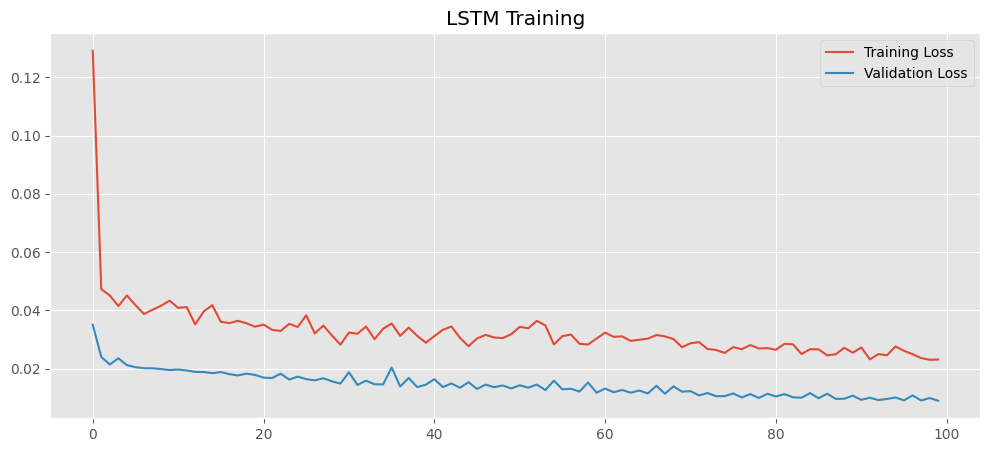

In [133]:
plt.figure(figsize=(12,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.legend()

plt.title("LSTM Training")

plt.show()

In [141]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate LSTM metrics
lstm_mae = mean_absolute_error(actual.flatten(), pred.flatten())

lstm_rmse = np.sqrt(
    mean_squared_error(actual.flatten(), pred.flatten())
)

lstm_mape = np.mean(
    np.abs((actual.flatten() - pred.flatten()) / actual.flatten())
) * 100

lstm_r2 = r2_score(
    actual.flatten(),
    pred.flatten()
)

print("LSTM Results")
print("--------------------------")
print("MAE :", round(lstm_mae,2))
print("RMSE :", round(lstm_rmse,2))
print("MAPE :", round(lstm_mape,2))
print("R2 :", round(lstm_r2,4))

LSTM Results
--------------------------
MAE : 1993.15
RMSE : 2758.49
MAPE : 3.67
R2 : 0.6017


In [144]:
lstm_metrics = pd.DataFrame({

    "Model":["LSTM"],

    "MAE":[lstm_mae],

    "RMSE":[lstm_rmse],

    "MAPE":[lstm_mape],

    "R2":[lstm_r2]

})

lstm_metrics

,Model,MAE,RMSE,MAPE,R2
0,LSTM,1993.146324,2758.494068,3.666989,0.60171


Prediction

In [145]:
pred = model.predict(
    X_test
)

pred.shape

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step


(104, 1)

In [146]:
pred = scaler.inverse_transform(pred)

actual = scaler.inverse_transform(y_test)

Evaluation

In [147]:
mae = mean_absolute_error(
    actual,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        pred
    )
)

mape = np.mean(
    np.abs(
        (actual-pred)
        /
        actual
    )
)*100

r2 = r2_score(
    actual,
    pred
)

print("MAE :",round(mae,2))

print("RMSE :",round(rmse,2))

print("MAPE :",round(mape,2))

print("R2 :",round(r2,4))

MAE : 1993.15
RMSE : 2758.49
MAPE : 3.67
R2 : 0.6017


Save Forecast

In [148]:
lstm_forecast = pd.DataFrame({

    "Actual":actual.flatten(),

    "Forecast":pred.flatten()

})

lstm_forecast.to_csv(

    "lstm_forecast.csv",

    index=False

)

lstm_forecast.head()

,Actual,Forecast
0,55848.940476,55474.296875
1,55762.125000,55699.214844
2,58684.714286,55790.476562
3,55917.589286,56940.425781
4,58163.470238,56454.875000


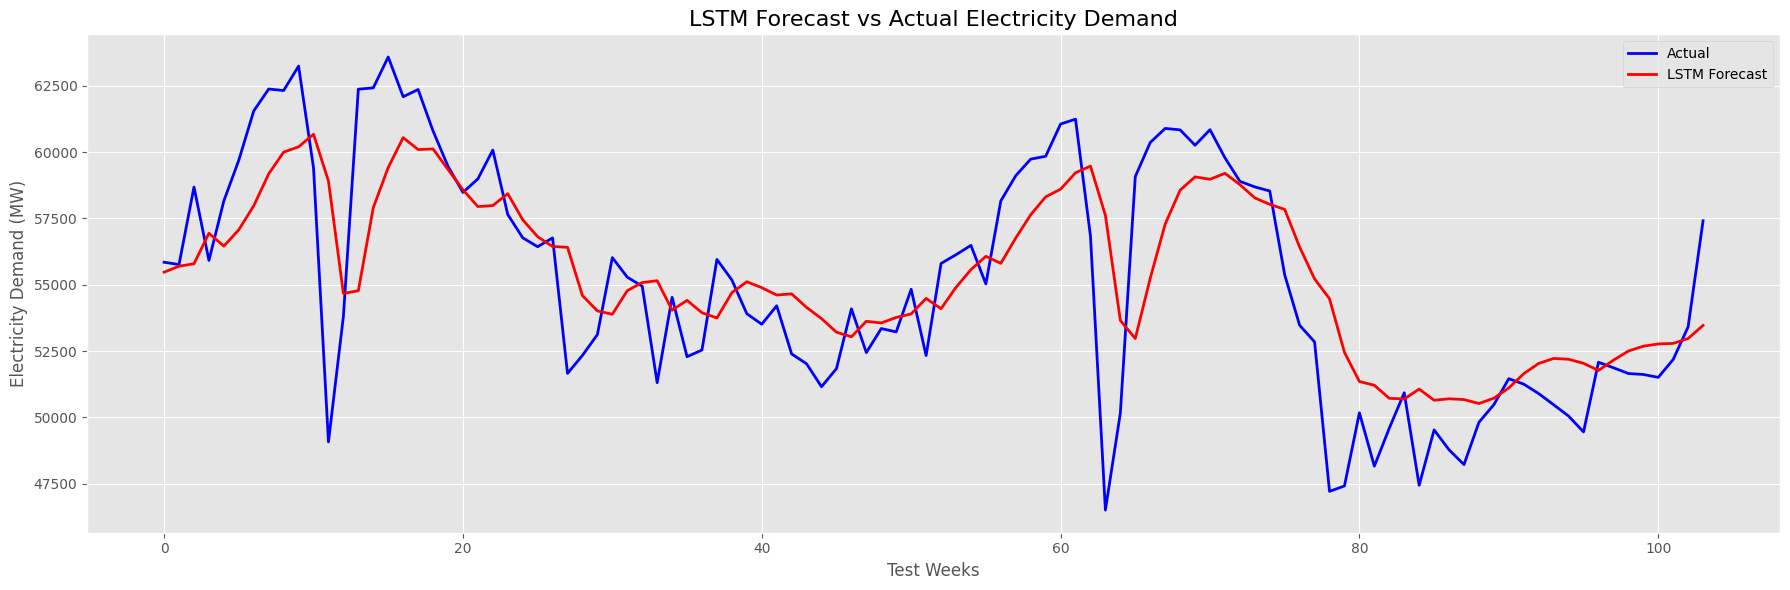

In [149]:
plt.figure(figsize=(18,6))

plt.plot(
    lstm_forecast["Actual"],
    label="Actual",
    linewidth=2,
    color="blue"
)

plt.plot(
    lstm_forecast["Forecast"],
    label="LSTM Forecast",
    linewidth=2,
    color="red"
)

plt.title("LSTM Forecast vs Actual Electricity Demand", fontsize=16)

plt.xlabel("Test Weeks", fontsize=12)

plt.ylabel("Electricity Demand (MW)", fontsize=12)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [150]:
lstm_metrics = pd.DataFrame({

    "Model":["LSTM"],

    "MAE":[mae],

    "RMSE":[rmse],

    "MAPE":[mape],

    "R2":[r2]

})

lstm_metrics

,Model,MAE,RMSE,MAPE,R2
0,LSTM,1993.146324,2758.494068,3.666989,0.60171


In [151]:
sarima_rmse = rmse
sarimax_rmse = rmse
lstm_rmse = rmse

Save Metrics CSV

In [152]:
lstm_metrics.to_csv(

    "lstm_metrics.csv",

    index=False

)

print("Saved Successfully")

Saved Successfully


##Compare All Models

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Final Model Comparison
# ==========================

results = pd.DataFrame({

    "Model":[
        "Mean",
        "Naïve",
        "Seasonal Naïve",
        "Drift",
        "SARIMA",
        "SARIMAX",
        "Random Forest",
        "Gradient Boosting",
        "LSTM"
    ],

    "MAE":[
        3788.833,
        3783.203,
        2318.521,
        4339.891,
        1963.878,
        5248.560,
        1501.451,
        1308.418,
        lstm_mae
    ],

    "RMSE":[
        4397.300,
        4459.109,
        3006.761,
        5117.957,
        2742.068,
        6479.630,
        2091.480,
        1761.025,
        lstm_rmse
    ],

    "MAPE":[
        6.969,
        6.790,
        4.409,
        8.050,
        3.631,
        9.990,
        2.816,
        2.458,
        lstm_mape
    ],

    "R²":[
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        0.606,
        -2.198,
        0.771,
        0.838,
        lstm_r2
    ]

})

results = results.round(3)

print("="*70)
print("GERMAN ELECTRICITY DEMAND FORECASTING")
print("MODEL COMPARISON")
print("="*70)

display(results)

# Save CSV
results.to_csv(
    "Final_Model_Comparison.csv",
    index=False
)

print("\nResults saved as Final_Model_Comparison.csv")

GERMAN ELECTRICITY DEMAND FORECASTING
MODEL COMPARISON


,Model,MAE,RMSE,MAPE,R²
0,Mean,3788.833,4397.300,6.969,NaN
1,Naïve,3783.203,4459.109,6.790,NaN
2,Seasonal Naïve,2318.521,3006.761,4.409,NaN
3,Drift,4339.891,5117.957,8.050,NaN
4,SARIMA,1963.878,2742.068,3.631,0.606
5,SARIMAX,5248.560,6479.630,9.990,-2.198
6,Random Forest,1501.451,2091.480,2.816,0.771
7,Gradient Boosting,1308.418,1761.025,2.458,0.838
8,LSTM,1993.146,2758.494,3.667,0.602



Results saved as Final_Model_Comparison.csv


In [154]:
best = all_models.loc[
    all_models["RMSE"].idxmin()
]

print("="*60)
print("BEST MODEL")
print("="*60)

print(best)

BEST MODEL
Model    Gradient Boosting
RMSE           1761.024724
Name: 4, dtype: object


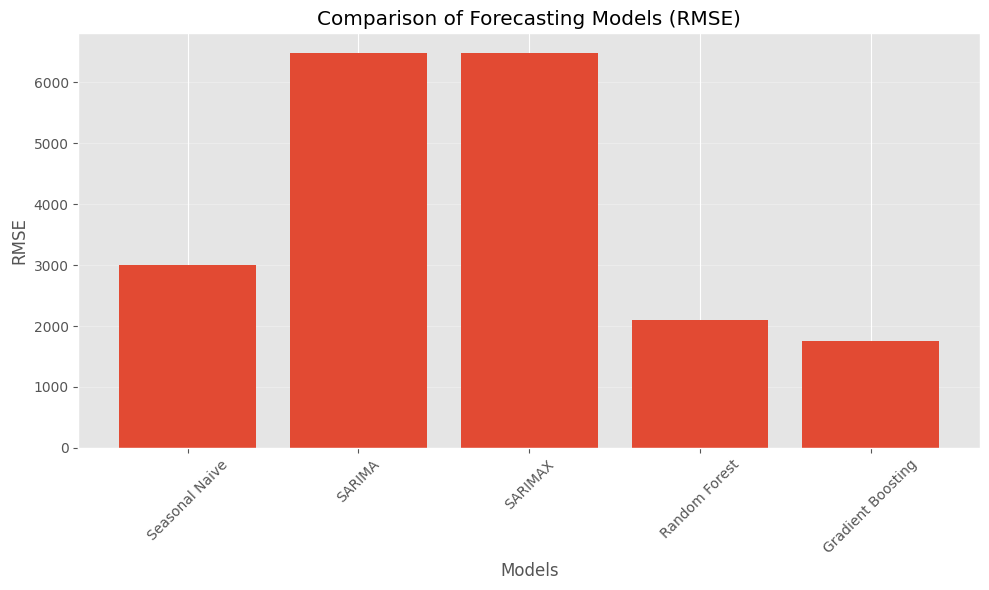

In [155]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    all_models["Model"],
    all_models["RMSE"]
)

plt.title("Comparison of Forecasting Models (RMSE)")

plt.xlabel("Models")

plt.ylabel("RMSE")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [156]:
test_exog

,load,temp_mean,HDD,CDD
2018-10-14,55848.940476,14.400000,3.600000,0.0
2018-10-21,55762.125000,11.957143,6.042857,0.0
2018-10-28,58684.714286,8.842857,9.157143,0.0
2018-11-04,55917.589286,8.685714,9.314286,0.0
2018-11-11,58163.470238,9.671429,8.328571,0.0
...,...,...,...,...
2020-09-06,51617.744048,15.985714,2.014286,0.0
2020-09-13,51507.630952,16.442857,1.557143,0.0
2020-09-20,52181.327381,17.242857,0.757143,0.0
2020-09-27,53411.934524,15.014286,2.985714,0.0


In [157]:
sarimax_actual = test_exog["load"]
sarimax_forecast = forecast_mean

In [158]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

sarimax_actual = np.asarray(test_exog["load"]).reshape(-1)
sarimax_forecast = np.asarray(forecast_mean).reshape(-1)

sarimax_mae = mean_absolute_error(sarimax_actual, sarimax_forecast)

sarimax_rmse = np.sqrt(
    mean_squared_error(sarimax_actual, sarimax_forecast)
)

sarimax_mape = np.mean(
    np.abs((sarimax_actual - sarimax_forecast) / sarimax_actual)
) * 100

sarimax_r2 = r2_score(
    sarimax_actual,
    sarimax_forecast
)

print("MAE :", round(sarimax_mae,2))
print("RMSE :", round(sarimax_rmse,2))
print("MAPE :", round(sarimax_mape,2))
print("R² :", round(sarimax_r2,4))

MAE : 5248.56
RMSE : 6479.63
MAPE : 9.99
R² : -1.1976
